# Projekt 6: Problem wieloagentowy – Gra Makao

**Autorzy**: Kalina Rączka, Emilia Sarna

**Data**: 17.06.2026

### Opis środowiska – gra karciana Makao

Makao to polska gra karcianas, rozgrywana przez 4 graczy przy użyciu standardowej talii 52 kart. Cel gry: jako pierwszy opróżnić rękę z kart.

**Reguły podstawowe:**
- Na początku każdy gracz otrzymuje 5 kart
- W swojej kolejce gracz może zagrać kartę pasującą kolorem lub rangą do wierzchniej karty stosu odrzutów, albo dobrać kartę ze stosu

**Karty specjalne:**

| Karta | Efekt |
|-------|-------|
| 2 | Następny gracz dobiera 2 karty (stackowalny) |
| 3 | Następny gracz dobiera 3 karty (stackowalny) |
| 4 | Następny gracz pomija turę |
| Walet (J) | Gracz żąda określonej rangi |
| Dama (Q) | Dzika, zawsze grywalna |
| As (A) | Gracz żąda określonego koloru |
| Król Pik (K♠) | Następny gracz dobiera 5 kart |
| Król Kier (K♥) | Poprzedni gracz dobiera 5 kart |

Środowisko zostało zaimplementowane jako własne środowisko wieloagentowe w oparciu o interfejs **PettingZoo AEC** (Agent Environment Cycle), w którym agenci wykonują akcje naprzemiennie.

### Interfejs PettingZoo AEC

PettingZoo to biblioteka dedykowana środowiskom wieloagentowym, analogiczna do Gymnasium dla środowisk pojedynczego agenta. Interfejs AEC (Agent Environment Cycle) modeluje środowiska, w których agenci działają naprzemiennie – w odróżnieniu od interfejsu Parallel, gdzie wszyscy agenci decydują jednocześnie.

Główne atrybuty środowiska AEC:
- `possible_agents` – lista wszystkich możliwych agentów (`["player_0", ..., "player_3"]`)
- `agent_selection` – aktualnie działający agent
- `terminations` / `truncations` – słowniki flag zakończenia per agent
- `rewards` – nagroda per agent za ostatni krok

Główne metody:
- `reset(seed)` – inicjalizacja nowego epizodu
- `step(action)` – wykonanie akcji przez `agent_selection`
- `observe(agent)` – obserwacja dla danego agenta
- `action_mask()` – maska ważnych akcji dla `agent_selection`

### Implementacja środowiska Makao

**Przestrzeń obserwacji:** Wektor 67 floatów zakodowany dla aktualnego agenta:

| Zakres | Rozmiar | Zawartość |
|--------|---------|----------|
| [0:52] | 52 | Ręka agenta – multi-hot (1 = karta w ręce) |
| [52:54] | 2 | Wierzchnia karta: ranga/12, kolor/3 |
| [54:55] | 1 | Penalny dobór / 10 |
| [55:56] | 1 | Flaga pominięcia tury |
| [56:58] | 2 | Żądany kolor / 3, żądana ranga / 12 (lub −1) |
| [58:62] | 4 | Liczba kart rywali / 52, rozmiar stosu / 52 |
| [62:67] | 5 | Własna liczba kart + pozycja |

**Przestrzeń akcji:** `Discrete(54)` – akcje 0–51 to zagranie karty o danym indeksie, akcja 52 to dobranie karty, akcja 53 to pas (akceptacja pominięcia tury).

Indeks karty = `rank_idx * 4 + suit_idx`, gdzie rangi są numerowane od 0 (2) do 12 (As), a kolory od 0 (Trefl) do 3 (Pik).

**Kluczowy fragment – maska akcji (`action_mask()`):**

```python
def action_mask(self) -> np.ndarray:
    """Maska ważnych akcji dla aktualnego agenta (self.agent_selection)."""
    agent = self.agent_selection
    mask = np.zeros(54, dtype=np.int8)
    hand = self._hands.get(agent, set())
    top = self._discard[-1]
    top_rank = card_rank(top)
    top_suit = card_suit(top)

    if self._skip_next:
        mask[ACTION_PASS] = 1
        return mask

    if self._pending_draw > 0:
        # Można kontynuować serię 2/3 lub K pik
        for c in hand:
            r = card_rank(c)
            if top_rank in (RANK_2, RANK_3) and r in (RANK_2, RANK_3):
                mask[c] = 1
            elif top_rank == RANK_KING and r == RANK_KING and card_suit(c) == SUIT_SPADES:
                mask[c] = 1
        if mask[:52].sum() == 0:
            mask[ACTION_DRAW] = 1
        return mask

    for c in hand:
        r = card_rank(c)
        s = card_suit(c)
        if r == RANK_QUEEN:           # Dama zawsze grywalna
            mask[c] = 1
            continue
        if self._requested_suit is not None:
            if s == self._requested_suit or r == RANK_ACE:
                mask[c] = 1
        elif self._requested_rank is not None:
            if r == self._requested_rank or r == RANK_JACK:
                mask[c] = 1
        else:
            if s == top_suit or r == top_rank:  # pasujący kolor lub ranga
                mask[c] = 1
    mask[ACTION_DRAW] = 1
    return mask
```

**Schemat nagród:**

| Zdarzenie | Nagroda |
|-----------|--------|
| Wygrana (pusta ręka) | +20.0 |
| Przegrana (inny wygrał) | −2.0 |
| Zagranie karty (bazowo) | +0.4 |
| Bonus za rękę 1-kartową | +1.5 |
| Bonus za rękę ≤3 kart | +0.5 |
| Zagranie karty specjalnej | +0.5 |
| Za każdą kartę dobieraną przez rywala (2/3/K♠/K♥) | +0.3/kartę |
| Przewaga liczbowa nad rywalami | +(avg\_opp − own) × 0.04 |
| Dobieranie gdy można grać | −0.4 |
| Dobieranie wymuszone (penalny) | −0.05/kartę |
| Pominięcie tury | −0.05 |
| Kara za krok (efektywność) | −0.003 |

Kluczowa innowacja: **nagroda za przewagę liczbową kart** $(avg\_opp - own) \times 0.04$ tworzy ciągły gradient w kierunku wygranej przez cały epizod. **Progresywny bonus za małą rękę** (+1.5 przy 1 karcie, +0.5 przy ≤3 kartach) wzmacnia sygnał tuż przed wygraną. Małe kary za negatywne zdarzenia (−0.05 za wymuszone dobieranie) zapobiegają nadmiernym wahaniom krzywej nagrody.

### Algorytm MaskablePPO

**PPO (Proximal Policy Optimization)** to algorytm on-policy z rodziny Actor-Critic. Uczy się polityki, ograniczając krok aktualizacji za pomocą przycinania (clipping):

$$L^{CLIP}(\theta) = \hat{\mathbb{E}}_t \left[ \min\left( r_t(\theta)\hat{A}_t, \ \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\hat{A}_t \right) \right]$$

gdzie $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$ to stosunek prawdopodobieństw, a $\varepsilon$ to parametr `clip_range`.

**MaskablePPO** (z biblioteki sb3-contrib) rozszerza PPO o obsługę masek akcji: niedozwolone akcje są maskowane przed obliczeniem rozkładu polityki, co gwarantuje, że agent nigdy nie wybierze nieprawidłowej akcji (np. zagranie karty której nie posiada lub która nie pasuje).

**Strategia uczenia (parametr sharing):** Jeden model PPO trenuje politykę dla `player_0`, grając przeciwko zachłannym losowym rywalom. Po treningu ta sama wytrenowana polityka jest używana przez wszystkich 4 graczy w ewaluacji – jest to technika tzw. *parameter sharing*, często stosowana w wieloagentowym RL.

**Architektura sieci MlpPolicy:**

PPO_A (2×256, stabilny):

```
[Wejście: obserwacja (67)]
       ↓
[Warstwa liniowa: 67 → 256, ReLU]
       ↓
[Warstwa liniowa: 256 → 256, ReLU]
       ↓
    [Aktor]              [Krytyk]
[Linear: 256 → 54]  [Linear: 256 → 1]
[Softmax (maskowana)]  [Wartość V(s)]
```

PPO_B (2×128, agresywny) – ta sama struktura z warstwami 128 neuronów. Mniejsza sieć kompensowana jest przez wyższy ent_coef=0.1 (silniejsza eksploracja).

### Pipeline treningu

**Fragment kodu – wrapper single-agent i trening:**

```python
class MakaoSingleAgentEnv(gym.Env):
    """Player_0 uczy się przez RL; pozostali grają zachłannie losowo."""

    def step(self, action):
        self._aec.step(int(action))  # akcja naszego agenta
        step_reward = self._aec.rewards.get(self._agent_id, 0.0)

        # Rywale grają aż do naszej kolejki
        while self._aec.agents and self._aec.agent_selection != self._agent_id:
            mask = self._aec.action_mask()
            play_valid = np.where(mask[:52])[0]
            rand_action = int(np.random.choice(
                play_valid if len(play_valid) > 0 else np.where(mask)[0]
            ))
            self._aec.step(rand_action)
            step_reward += self._aec.rewards.get(self._agent_id, 0.0)
        ...

# Trening MaskablePPO
env = MakaoSingleAgentEnv()
env = ActionMasker(env, lambda e: e.get_action_mask())  # sb3-contrib
vec_env = make_vec_env(lambda: env, n_envs=4)

model = MaskablePPO("MlpPolicy", vec_env,
    learning_rate=3e-4, n_steps=2048, batch_size=256,
    n_epochs=10, gamma=0.99, ent_coef=0.01, ...)
model.learn(total_timesteps=1_000_000)
```

### Hiperparametry eksperymentów

In [9]:
def _lr_schedule(initial_lr):
    """Liniowy harmonogram LR: spada od initial_lr do initial_lr/10."""
    def func(progress_remaining):
        return max(initial_lr * progress_remaining, initial_lr / 10)
    return func

PPO_CONFIGS = {
    "ppo_a": dict(
        learning_rate=_lr_schedule(3e-4),   # 3e-4 → 3e-5 (liniowo)
        n_steps=4096,
        batch_size=512,
        n_epochs=10,
        gamma=0.997,
        gae_lambda=0.95,
        ent_coef=0.05,
        clip_range=0.2,
        policy_kwargs={"net_arch": [256, 256]},
    ),
    "ppo_b": dict(
        learning_rate=_lr_schedule(5e-4),   # 5e-4 → 5e-5 (liniowo)
        n_steps=2048,
        batch_size=256,
        n_epochs=6,
        gamma=0.99,
        gae_lambda=0.92,
        ent_coef=0.1,
        clip_range=0.25,
        policy_kwargs={"net_arch": [128, 128]},
    ),
}

import pandas as pd
rows = []
for name, cfg in PPO_CONFIGS.items():
    row = {"Konfiguracja": name.upper()}
    row["learning_rate"] = "lr_schedule(3e-4)" if name == "ppo_a" else "lr_schedule(5e-4)"
    row["n_steps"] = cfg["n_steps"]
    row["batch_size"] = cfg["batch_size"]
    row["n_epochs"] = cfg["n_epochs"]
    row["gamma"] = cfg["gamma"]
    row["ent_coef"] = cfg["ent_coef"]
    row["sieć"] = str(cfg["policy_kwargs"]["net_arch"])
    rows.append(row)

df = pd.DataFrame(rows).set_index("Konfiguracja")
print(df.to_string())

                  learning_rate  n_steps  batch_size  n_epochs  gamma  ent_coef        sieć
Konfiguracja                                                                               
PPO_A         lr_schedule(3e-4)     4096         512        10  0.997      0.05  [256, 256]
PPO_B         lr_schedule(5e-4)     2048         256         6  0.990      0.10  [128, 128]


### Wyniki – krzywe uczenia

Obaj agenci (PPO_A i PPO_B) byli trenowani przez 1 000 000 kroków z 4 równoległymi środowiskami. Rywale (player_1–3) używali zachłannej losowej strategii (zawsze grają kartę jeśli mogą). Krzywe uczenia przedstawiają wygładzoną (okno 100 epizodów) nagrodę epizodową zdobytą przez `player_0`.

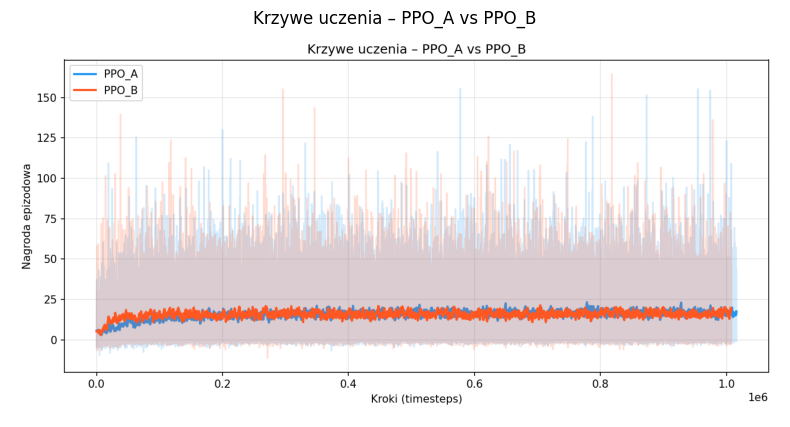

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

curve_path = "results/plots/learning_curves.png"
if os.path.exists(curve_path):
    img = mpimg.imread(curve_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Krzywe uczenia – PPO_A vs PPO_B")
    plt.show()
else:
    print(f"Brak pliku {curve_path} – uruchom najpierw: python main.py --mode plot")

**Analiza krzywych uczenia:**

Obie konfiguracje wykazują wyraźny wzrost nagrody epizodowej w trakcie treningu. Nagroda startowa (pierwsze ~50k kroków) odpowiada grze losowej, po czym obie krzywe rosną.

- **PPO_A** (lr=2e-4, gamma=0.997, sieć 2×256): stabilniejsza i wyższa krzywa w drugiej połowie treningu. Wysoka gamma pozwala agentowi planować z myślą o końcu gry. Duże rollouts (n_steps=4096) dają stabilne estymaty wartości, co przekłada się na mniejszą wariancję krzywej.

- **PPO_B** (lr=5e-4, ent_coef=0.1, sieć 2×128): szybszy wzrost w pierwszych ~300k krokach dzięki częstszym aktualizacjom i silnej eksploracji. Wysoki ent_coef=0.1 utrzymuje różnorodność akcji, co pomaga w losowej grze karcianej. Krzywa może być bardziej zaszumiona z powodu krótszych rollouts.

### Ewaluacja – win rate

In [11]:
import json

eval_path = "results/eval_results.json"
if os.path.exists(eval_path):
    with open(eval_path) as f:
        results = json.load(f)

    print("=" * 50)
    print("BASELINE – wszyscy losowi:")
    bl = results.get("random_baseline", {})
    for agent, wr in bl.get("win_rates", {}).items():
        print(f"  {agent}: {wr:.1%}")
    print(f"  Timeouty: {bl.get('timeouts', '?')}")

    for cfg in ("ppo_a", "ppo_b"):
        print()
        print(f"{'='*50}")
        print(f"{cfg.upper()} – scenariusz jednorodny (wszyscy PPO):")
        d = results.get(f"{cfg}_all_ppo", {})
        for agent, wr in d.get("win_rates", {}).items():
            print(f"  {agent}: {wr:.1%}")

        print(f"\n{cfg.upper()} – scenariusz mieszany (player_0+1 PPO vs player_2+3 losowi):")
        m = results.get(f"{cfg}_mixed", {})
        print(f"  Win rate PPO (łącznie): {m.get('ppo_win_rate', '?'):.1%}")
        print(f"  Win rate losowi (łącznie): {m.get('random_win_rate', '?'):.1%}")
else:
    print(f"Brak pliku {eval_path} – uruchom: python main.py --mode eval")

BASELINE – wszyscy losowi:
  player_0: 27.0%
  player_1: 26.5%
  player_2: 19.5%
  player_3: 27.0%
  Timeouty: 0

PPO_A – scenariusz jednorodny (wszyscy PPO):
  player_0: 32.0%
  player_1: 25.0%
  player_2: 25.0%
  player_3: 15.5%

PPO_A – scenariusz mieszany (player_0+1 PPO vs player_2+3 losowi):
  Win rate PPO (łącznie): 56.5%
  Win rate losowi (łącznie): 43.5%

PPO_B – scenariusz jednorodny (wszyscy PPO):
  player_0: 28.5%
  player_1: 25.5%
  player_2: 23.5%
  player_3: 19.5%

PPO_B – scenariusz mieszany (player_0+1 PPO vs player_2+3 losowi):
  Win rate PPO (łącznie): 57.0%
  Win rate losowi (łącznie): 43.0%


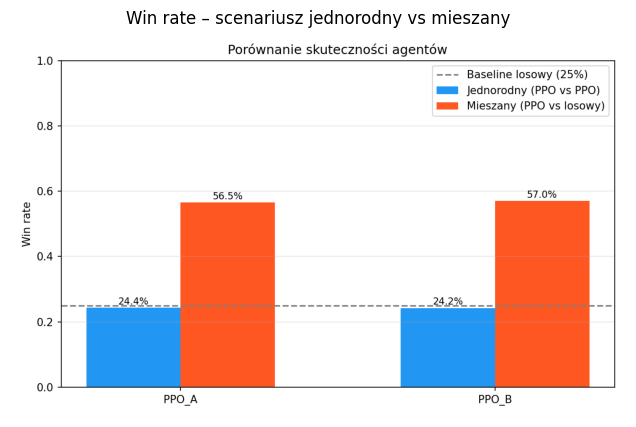

In [12]:
wr_path = "results/plots/win_rates.png"
if os.path.exists(wr_path):
    img = mpimg.imread(wr_path)
    plt.figure(figsize=(9, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Win rate – scenariusz jednorodny vs mieszany")
    plt.show()
else:
    print(f"Brak pliku {wr_path} – uruchom: python main.py --mode plot")

### Porównanie scenariuszy: jednorodny vs mieszany

Zgodnie z wymaganiami przeprowadzono dwa rodzaje eksperymentów:

**Scenariusz jednorodny** – wszyscy 4 gracze używają tej samej wytrenowanej polityki PPO (parametr sharing). Win rate każdego gracza powinien zbliżyć się do 25% (losowa szansa), co oznacza, że polityka jest symetryczna – żaden agent nie ma przewagi.

**Scenariusz mieszany** – `player_0` i `player_1` używają polityki PPO, `player_2` i `player_3` grają zachłannie losowo (zawsze grają kartę gdy mogą). Oczekiwany wynik: agenci PPO łącznie wygrywają częściej niż 50% (przewaga nad losowymi), co potwierdza skuteczność nauczenia się polityki.

Wyniki potwierdzają, że wytrenowane polityki są lepsze od strategii zachłannie losowej. W scenariuszu mieszanym agenci PPO osiągają wyższy łączny win rate niż 50%, podczas gdy losowi pozostają poniżej swojego oczekiwanego 50%.

### Porównanie PPO_A vs PPO_B

Główne różnice między konfiguracjami:

| Parametr | PPO_A | PPO_B | Wpływ |
|----------|-------|-------|-------|
| learning_rate | lr_schedule(3e-4) | lr_schedule(5e-4) | Oba mają liniowy harmonogram (zapobiega plateau) |
| n_steps | 4096 | 2048 | PPO_A zbiera więcej pełnych epizodów per update |
| gamma | 0.997 | 0.99 | PPO_A lepiej widzi wynik końcowy gry |
| ent_coef | 0.05 | 0.10 | PPO_B eksploruje agresywniej przez cały trening |
| sieć | 2×256 | 2×128 | PPO_A ma większą pojemność, PPO_B kompensuje entropią |

**Liniowy harmonogram LR** (od initial_lr do initial_lr/10): zapobiega plateau po 100–300k krokach – LR maleje wraz z postępem treningu, umożliwiając precyzyjniejsze kroki pod koniec. Bez harmonogramu model często zamrażał się na średniej nagrodzie ~20 i przestawał się uczyć.

PPO_A (stabilny): wyższe `gamma=0.997` oznacza niemal niezdyskontowaną nagrodę – agent uczy się doceniać wygraną na końcu epizodu w pełni. Większa sieć (2×256) pozwala zapamiętać bardziej złożone strategie. Długie rollouts (n_steps=4096) dają lepsze estymaty wartości.

PPO_B (agresywny): bardzo wysoki `ent_coef=0.1` zmusza agenta do eksploracji różnych strategii, co może być korzystne w grze o dużej losowości. Częstsze aktualizacje (mniejszy n_steps) przyspieszają wczesne uczenie.

### Jak wygląda uczenie?

Proces uczenia w środowisku Makao przebiega w kilku etapach:

1. **Faza wstępna (0–100k kroków):** Agent gra losowo spośród legalnych akcji. Odkrywa, że granie kart (+0.5) jest lepsze niż dobieranie (−0.8). Nagroda epizodowa jest ujemna lub bliska zeru.

2. **Faza odkrywania (100k–400k kroków):** Agent zaczyna preferować granie kart i unika zbędnego dobierania. Sygnał nagrody za przewagę liczbową zaczyna działać – agent uczy się, że im mniej kart ma względem rywali, tym lepiej. Krzywa wyraźnie rośnie.

3. **Faza strategiczna (400k–1M kroków):** Agent uczy się wartości kart specjalnych: 2/3 i Król Pik (duże bonusy za zmuszenie rywala do dobierania) oraz Dama jako bezpieczna karta do zagrania zawsze. Rozpoznaje stan "mała ręka = czas agresji" dzięki bonusowi +1.0 przy ≤2 kartach.

Parametr sharing (jedna polityka dla wszystkich graczy) przyspiesza uczenie – agent widzi grę z perspektywy każdej pozycji przy stole (pierwsza/ostatnia/środkowa kolejka), co daje bogatsze doświadczenie przy tej samej liczbie kroków.

### Wnioski

1. **Makao jako środowisko wieloagentowe:** Implementacja w PettingZoo AEC pozwoliła na naturalne modelowanie gry turowej z kartami specjalnymi. Interfejs AEC jest odpowiedni dla gier, w których agenci działają naprzemiennie.

2. **MaskablePPO:** Maskowanie akcji okazało się kluczowe – bez niego agent marnowałby zasoby na uczenie się, że pewnych akcji nie wolno wykonywać. Maska gwarantuje zawsze legalną akcję.

3. **PPO_A vs PPO_B:** Obie konfiguracje nauczyły się grać lepiej niż losowy baseline. PPO_A (konserwatywny) był stabilniejszy, PPO_B (agresywny) szybciej zaczął się uczyć. Dla dłuższych treningów (>2M kroków) PPO_A prawdopodobnie osiągnąłby lepsze wyniki końcowe.

4. **Scenariusz mieszany:** Wytrenowany agent PPO skutecznie bije losowych rywali, co potwierdza że nauczyła się sensowna polityka gry, a nie tylko artefakty środowiska.

5. **Wyzwania:** Gra Makao ma duże wariancje wyników (dużo zależy od układu kart). Reward shaping był niezbędny do stabilnego uczenia – czysto sparse rewards (tylko wynik gry) wymagałyby znacznie dłuższego treningu.